In [39]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from tqdm import tqdm
import joblib
from sklearn.pipeline import make_pipeline
import seaborn as sns
import os
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from tqdm import tqdm
import joblib
from sklearn.pipeline import make_pipeline
import utils
from scipy.stats import ttest_1samp

In [3]:
plt.rcParams['axes.grid'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')


DATABASE_PATH = Path('../../Database/inhouse_dataset/')
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')
DOCUMENTS_PATH = Path('../documents')
DATA_PATH.mkdir(exist_ok=True)
RESULTS_PATH.mkdir(exist_ok=True)
PLOTS_PATH.mkdir(exist_ok=True)
DOCUMENTS_PATH.mkdir(exist_ok=True)

In [15]:
NAME = 'inhouse_BNA'

motif_map_color_dict = dict(affect='#d66c7a',valuation='#f6d44a',  social='#8ab3d4')
MOTIF_LIST = ['affect', 'valuation', 'social']

SUBJECT_DF = pd.read_excel(DATA_PATH / 'subjects.xlsx')
SEED_DF = pd.read_excel(DATA_PATH / 'seeds.xlsx')
SEED_LIST = SEED_DF['BNA'].dropna().to_list()  + SEED_DF['MDTB'].dropna().to_list()

full_subject_list = SUBJECT_DF['subjects'].dropna().to_list()
X_dict = joblib.load(DATA_PATH / NAME / 'X.dict.pkl')
y_dict = joblib.load(DATA_PATH / NAME / 'y.dict.pkl')
mask_array_list = []
for subject in full_subject_list:
    mask_file = DATABASE_PATH / "T1w" / subject / (subject + "_VMPFC2T1w.nii.gz")
    mask = nib.load(mask_file).get_fdata() > 0
    mask_array_list.append(mask[mask])
group_list = np.hstack([np.ones_like(x) * (i + 1) for i, x in enumerate(mask_array_list)])


predict map affective 0.5236070641500157
predict map valuation 0.33907703714170595
predict map social 0.3582680422061305


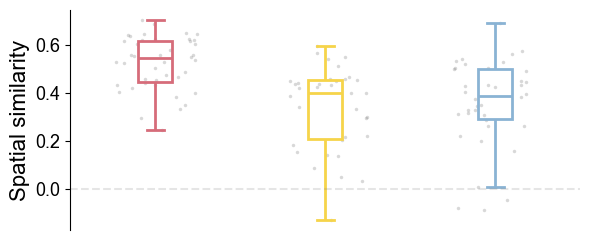

In [32]:

fig, ax = plt.subplots(figsize=(6, 2.5))
for i, motif in enumerate(MOTIF_LIST):
    y_array = y_dict[motif]
for i, motif_name in enumerate(MOTIF_LIST):
    y_array = y_dict[motif_name]
    include_subject_list = SUBJECT_DF[motif_name].dropna().to_list()
    include_group_list = np.array([i + 1 for i, x in enumerate(full_subject_list) if x in include_subject_list])
    group_mask = [x in include_group_list for x in group_list]
    this_group_list = group_list[group_mask]


    FC_model = joblib.load( RESULTS_PATH / NAME/ f'FC_{motif_name}.LinearRegression.pkl')
    FC_X_array = X_dict['FC'][group_mask]
    FC_predict_y_array = FC_model.predict(FC_X_array)


    SC_model = joblib.load( RESULTS_PATH / NAME/ f'SC_{motif_name}.LinearRegression.pkl')
    SC_X_array = X_dict['SC'][group_mask]
    SC_predict_y_array = SC_model.predict(SC_X_array)

    r_list = utils.get_r.calculate_prediction_r(this_group_list, FC_predict_y_array, SC_predict_y_array)
    print('predict map', motif_name, np.mean(r_list))

    
    plot_data = r_list
    sns.stripplot(
        y=plot_data,
        x=i,
        ax=ax,
        size=2.5,
        color=".4",
        alpha=0.25,
        jitter=0.25,
        zorder=1
    )

    sns.boxplot(
        x=i,
        y=plot_data,
        ax=ax,
        # color=,
        boxprops={'facecolor': 'none'},  # 【关键】将箱体内部完全掏空，变成透明
        linecolor=motif_map_color_dict[motif_name],
        width=0.2,
        linewidth=2,
        fliersize=0,
        zorder=2
    )

ax.set_xlim(-0.5, 2.5)
ax.set_xticks(range(3))
ax.set_xticklabels([])
ax.set_yticks([0, 0.2, 0.4, 0.6,])
ax.set_yticklabels([0.0, 0.2, 0.4, 0.6,], fontsize=13)
ax.hlines(y=0, xmin=-0.5, xmax=2.5, color='gray', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params( bottom=False,)
ax.set_ylabel('Spatial similarity', fontsize=16)
fig.tight_layout()

fig.savefig(PLOTS_PATH / 'predicted_map_similarity.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'predicted_map_similarity.svg', **PLOT_KWARGS_DICT)


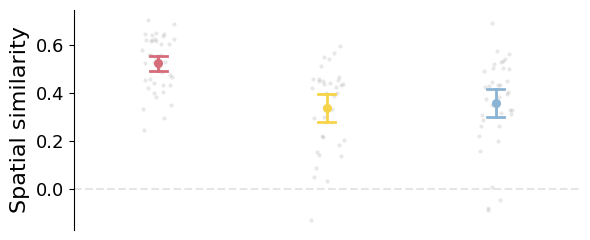

In [58]:

fig, ax = plt.subplots(figsize=(6, 2.5))
for i, motif in enumerate(MOTIF_LIST):
    y_array = y_dict[motif]
for i, motif_name in enumerate(MOTIF_LIST):
    y_array = y_dict[motif_name]
    include_subject_list = SUBJECT_DF[motif_name].dropna().to_list()
    include_group_list = np.array([i + 1 for i, x in enumerate(full_subject_list) if x in include_subject_list])
    group_mask = [x in include_group_list for x in group_list]
    this_group_list = group_list[group_mask]


    FC_model = joblib.load( RESULTS_PATH / NAME/ f'FC_{motif_name}.LinearRegression.pkl')
    FC_X_array = X_dict['FC'][group_mask]
    FC_predict_y_array = FC_model.predict(FC_X_array)


    SC_model = joblib.load( RESULTS_PATH / NAME/ f'SC_{motif_name}.LinearRegression.pkl')
    SC_X_array = X_dict['SC'][group_mask]
    SC_predict_y_array = SC_model.predict(SC_X_array)

    r_list = utils.get_r.calculate_prediction_r(this_group_list, FC_predict_y_array, SC_predict_y_array)

    t, p = ttest_1samp(r_list, 0)
    print(f'{motif_name}: mean={np.mean(r_list):.3f} median={np.median(r_list):.3f} sd={np.std(r_list):.3f}  t={t:.3f}, p={p:.4f}')
    plot_data = r_list
    sns.stripplot(
        y=plot_data,
        x=i,
        ax=ax,
        size=3,
        color=".4",
        alpha=0.15,
        jitter=0.1,
        zorder=1,

    )

    sns.pointplot(
        x=i,
        y=plot_data,
        ax=ax,
        # color=,
        # boxprops={'facecolor': 'none'},  # 【关键】将箱体内部完全掏空，变成透明
        color=motif_map_color_dict[motif_name],
        linewidth=2,
        capsize=0.1,
        zorder=2
    )

ax.set_xlim(-0.5, 2.5)
ax.set_xticks(range(3))
ax.set_xticklabels([])
ax.set_yticks([0, 0.2, 0.4, 0.6,])
ax.set_yticklabels([0.0, 0.2, 0.4, 0.6,], fontsize=13)
ax.hlines(y=0, xmin=-0.5, xmax=2.5, color='gray', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params( bottom=False,)
ax.set_ylabel('Spatial similarity', fontsize=16)
fig.tight_layout()

fig.savefig(PLOTS_PATH / 'predicted_map_similarity.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'predicted_map_similarity.svg', **PLOT_KWARGS_DICT)


affective, r=0.1026, p=0.1014
valuation, r=0.0211, p=0.7368
social, r=0.0916, p=0.1441


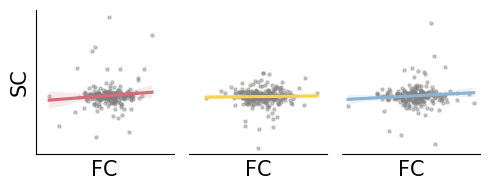

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(5, 2), sharex=True, sharey=True)

for i, motif_name in enumerate(MOTIF_LIST):
    FC_model = joblib.load( RESULTS_PATH / NAME/ f'FC_{motif_name}.LinearRegression.pkl')
    SC_model = joblib.load( RESULTS_PATH / NAME/ f'SC_{motif_name}.LinearRegression.pkl')
    r, p =pearsonr(FC_model.coef_, SC_model.coef_)
    print(f'{motif_name}, r={r:.4f}, p={p:.4f}')
    ax = axes[i]
    sns.regplot(x=FC_model.coef_, y=SC_model.coef_, ax=ax, line_kws={'color': motif_map_color_dict[motif_name]},
                scatter_kws={'marker': '.', 's': 5, 'alpha': 0.4, 'color':'gray'})
    ax.set_xlabel('FC', fontsize=15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i != 0:
        ax.spines['left'].set_visible(False)
    else:
        ax.set_ylabel('SC', fontsize=15)

    ax.tick_params(left=False, bottom=False,)
    ax.set_xticks([])
    ax.set_yticks([])


plt.subplots_adjust(wspace=0.5)
fig.tight_layout()

fig.savefig(PLOTS_PATH / 'model_weights.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'model_weights.svg', **PLOT_KWARGS_DICT)